# Stage 04 — Augmented Model (Training & Tuning)

Repeats **Stage 03**'s exact flow -- load windowed dataset, tune the `RNNForecaster` LSTM with **Optuna (TPE) + ASHA** over **expanding-window walk-forward** cross-validation, evaluate on a held-out test period, save the run -- on the **pattern-augmented** feature set from Stage 02 (base features + the six `chart_patterns` flag columns).

Only two things differ from Stage 03: the input `.npz` (`AUGMENTED_WINDOWS_FILENAME` instead of `BASELINE_WINDOWS_FILENAME`) and the saved run's label (`'augmented'` instead of `'baseline'`). The model, tuning search space, CV scheme, and evaluation are identical, since `RNNForecaster` is feature-count-agnostic and the whole point of Stage 04 is an apples-to-apples comparison against Stage 03 in Stage 05.


## Environment setup (Google Colab)

Mounts the Drive, clones the repo via the `GITHUB_TOKEN` secret, and installs dependencies (including `ray[tune]` + `optuna` for tuning).


In [ ]:
import os
import sys

from google.colab import drive, userdata

drive.mount('/content/drive')

GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')
GITHUB_USER = 'jesseingraham'
REPO_NAME = 'comp-653-stock-prediction-i'
REPO_PATH = f'/content/{REPO_NAME}'

if not os.path.exists(REPO_PATH):
    !git clone https://{GITHUB_TOKEN}@github.com/{GITHUB_USER}/{REPO_NAME}.git

os.chdir(REPO_PATH)
if REPO_PATH not in sys.path:
    sys.path.append(REPO_PATH)

!pip install -r requirements.txt


## Imports & configuration

In [2]:
import os

import matplotlib.pyplot as plt
import numpy as np
import torch

from config import DRIVE_DATA_PATH, DRIVE_MODELS_PATH
from src.features.windowing import AUGMENTED_WINDOWS_FILENAME
from src.models.rnn_forecaster import RNNForecaster
from sklearn.preprocessing import StandardScaler

from src.models.trainer import evaluate_on_test, tune_model
from src.utils import artifacts, plotting

print('CUDA available:', torch.cuda.is_available())


CUDA available: False


## 1. Load the windowed feature dataset

Produced by **Stage 02** (`02_feature_engineering`) and saved to the Drive `data/` folder as an `.npz` holding:

- `X` — `(n, window_size, num_features)` float32, chronologically ordered
- `y` — `(n, horizon)` float32 log-return targets
- `dates` — `(n,)` the first target date of each window

This is the **pattern-augmented** feature set (base features + the six `chart_patterns` flag columns); Stage 03 loads the baseline (price-only) file instead. Its `num_features` will be 6 higher than Stage 03's.


In [3]:
# Written by Stage 02 (02_feature_engineering).
WINDOW_FILE = AUGMENTED_WINDOWS_FILENAME

data = np.load(os.path.join(DRIVE_DATA_PATH, WINDOW_FILE), allow_pickle=True)
X = data['X'].astype('float32')
y = data['y'].astype('float32')
dates = data['dates'] if 'dates' in data.files else None

print('X:', X.shape, '| y:', y.shape, '| num_features:', X.shape[-1])


X: (4950, 30, 12) | y: (4950, 1) | num_features: 12


## 2. Chronological train/test split

Hold out the most recent slice as the test set; the remainder is the development set that walk-forward CV tunes on. No shuffling — order is preserved so the model never trains on the future. Same `TEST_FRAC` as Stage 03, so the split boundaries line up for the Stage 05 comparison.


In [4]:
TEST_FRAC = 0.15  # most-recent ~15% held out for final evaluation
n_test = int(len(X) * TEST_FRAC)

X_dev, X_test = X[:-n_test], X[-n_test:]
y_dev, y_test = y[:-n_test], y[-n_test:]
test_dates = dates[-n_test:] if dates is not None else None

print(f'dev: {X_dev.shape[0]} windows | test: {X_test.shape[0]} windows')


dev: 4208 windows | test: 742 windows


## 3. Hyperparameter tuning (Optuna + ASHA, walk-forward)

Each trial trains one model per fold in lockstep and is scored on the mean validation RMSE across folds; ASHA stops weak trials early. Results persist to the Drive (`DRIVE_MODELS_PATH`) and are resumable after a disconnect. Same search space and `tune_kwargs` as Stage 03 -- only the data and `experiment_name` differ, so tuning cost and effort are comparable between the two runs. Flip `SMOKE_TEST` for a fast sanity run.


In [ ]:
import ray

ray.init(ignore_reinit_error=True, include_dashboard=False)

SMOKE_TEST = False
tune_kwargs = (
    dict(num_samples=4, max_epochs=6, n_folds=3)
    if SMOKE_TEST
    else dict(num_samples=30, max_epochs=50, n_folds=4)
)

results = tune_model(
    X_dev,
    y_dev,
    model_cls=RNNForecaster,
    storage_path=DRIVE_MODELS_PATH,
    experiment_name='augmented_rnn_tune',
    gpu_per_trial=0.25 if torch.cuda.is_available() else 0.0,
    scaler_factory=StandardScaler,  # refit per fold -> no leakage
    **tune_kwargs,
)

best = results.get_best_result('val_rmse', mode='min')
print('Best config:', best.config)
print('Best mean val RMSE:', round(best.metrics['val_rmse'], 5))


## 4. Tuning summary & charts

The 10 best configurations, then: per-trial performance, learning curves across trials (short curves = ASHA-stopped), and how validation RMSE responds to each hyperparameter.


In [6]:
results_df = results.get_dataframe()
results_df.sort_values('val_rmse').head(10)


,val_rmse,epoch,timestamp,checkpoint_dir_name,done,training_iteration,trial_id,date,time_this_iter_s,time_total_s,...,node_ip,time_since_restore,iterations_since_restore,config/hidden_size,config/num_layers,config/dropout,config/lr,config/batch_size,config/weight_decay,logdir
14,0.009813,49,1786509136,None,True,50,0c278212,2026-08-12_04-32-16,9.640916,241.134199,...,172.28.0.12,241.134199,50,32,2,0.043754,0.001649,64,0.000003,0c278212
7,0.009907,49,1786508339,None,True,50,0468a411,2026-08-12_04-18-59,9.128167,343.385724,...,172.28.0.12,343.385724,50,32,3,0.159284,0.002162,64,0.000004,0468a411
15,0.009941,19,1786509258,None,True,20,414a618a,2026-08-12_04-34-18,8.511461,119.865337,...,172.28.0.12,119.865337,20,32,2,0.031440,0.002181,32,0.000003,414a618a
24,0.009963,19,1786509648,None,True,20,a24028e7,2026-08-12_04-40-48,6.699210,123.556924,...,172.28.0.12,123.556924,20,32,2,0.002826,0.003106,32,0.000004,a24028e7
18,0.009987,19,1786509331,None,True,20,48a4b888,2026-08-12_04-35-31,3.277737,90.721455,...,172.28.0.12,90.721455,20,32,2,0.065104,0.001041,64,0.000001,48a4b888
4,0.010009,49,1786508432,None,True,50,ec3dc674,2026-08-12_04-20-32,32.081072,1226.286125,...,172.28.0.12,1226.286125,50,128,2,0.104438,0.000210,32,0.000005,ec3dc674
23,0.010033,19,1786509563,None,True,20,c49ca9e3,2026-08-12_04-39-23,4.717338,122.564976,...,172.28.0.12,122.564976,20,32,2,0.001333,0.003724,32,0.000004,c49ca9e3
13,0.010035,49,1786509126,None,True,50,957c1edf,2026-08-12_04-32-06,4.151286,245.494292,...,172.28.0.12,245.494292,50,32,2,0.034926,0.001811,64,0.000003,957c1edf
21,0.010069,19,1786509509,None,True,20,a2931913,2026-08-12_04-38-29,6.878770,161.051172,...,172.28.0.12,161.051172,20,32,3,0.195667,0.003310,64,0.000001,a2931913
8,0.010179,19,1786508874,None,True,20,33b1600f,2026-08-12_04-27-54,28.032591,518.300883,...,172.28.0.12,518.300883,20,128,2,0.367597,0.008402,128,0.000052,33b1600f


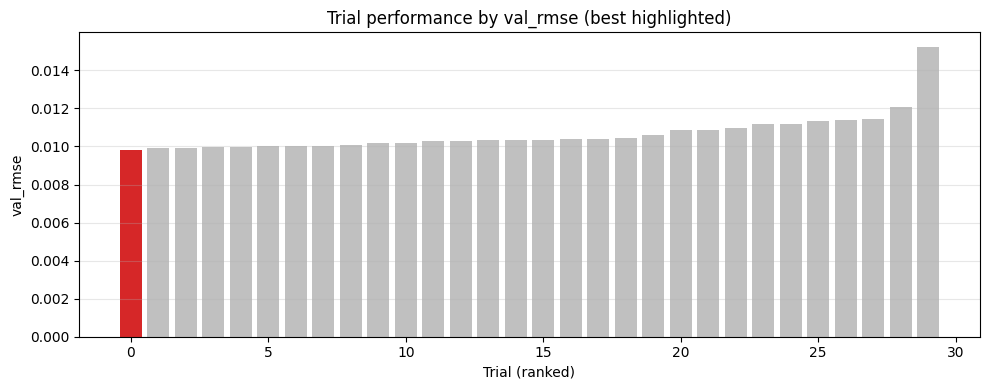

In [7]:
plotting.plot_trial_performance(results_df, metric='val_rmse', mode='min')
plt.show()


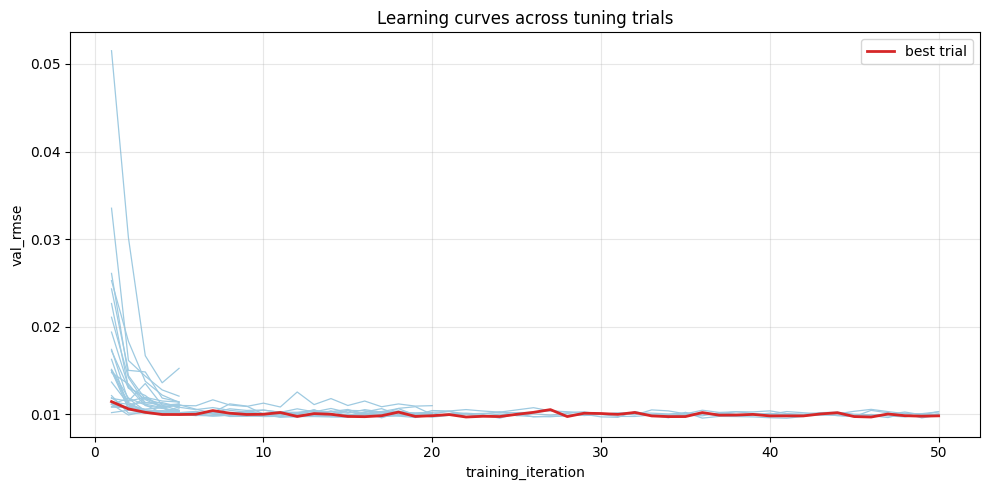

In [8]:
curves = [r.metrics_dataframe for r in results]
final_vals = [
    c['val_rmse'].iloc[-1] if 'val_rmse' in c else np.inf for c in curves
]
best_index = int(np.argmin(final_vals))

plotting.plot_learning_curves(curves, metric='val_rmse', best_index=best_index)
plt.show()


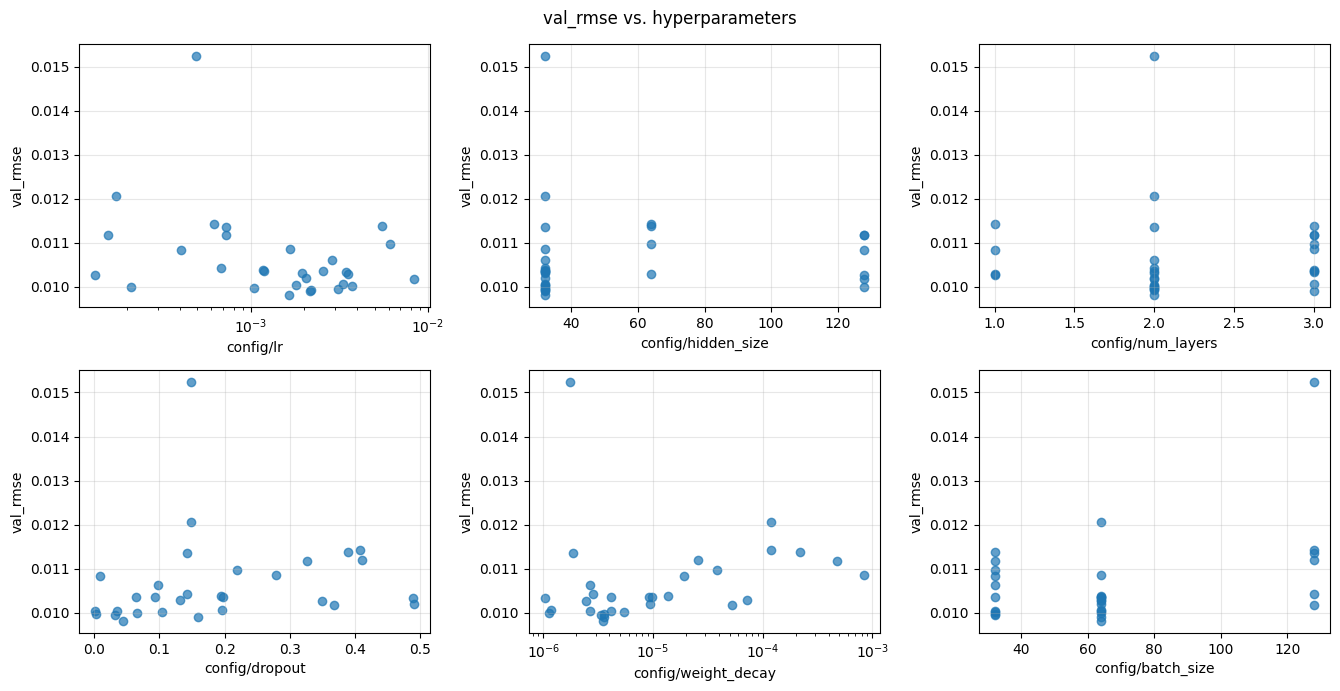

In [9]:
params = [
    f'config/{p}'
    for p in ['lr', 'hidden_size', 'num_layers', 'dropout',
              'weight_decay', 'batch_size']
]
plotting.plot_hyperparameter_effects(results_df, params, metric='val_rmse')
plt.show()


## 5. Final evaluation on the held-out test set

Retrain the best configuration on **all** development data, then score the untouched test period — reporting RMSE and directional (up/down) accuracy.


In [10]:
res = evaluate_on_test(
    best.config,
    X_dev,
    y_dev,
    X_test,
    y_test,
    model_cls=RNNForecaster,
    max_epochs=tune_kwargs['max_epochs'],
    scaler_factory=StandardScaler,
)

print(f"Test RMSE:                 {res['test_rmse']:.5f}")
print(f"Test directional accuracy: {res['test_directional_accuracy']:.3f}")


Test RMSE:                 0.00849
Test directional accuracy: 0.670


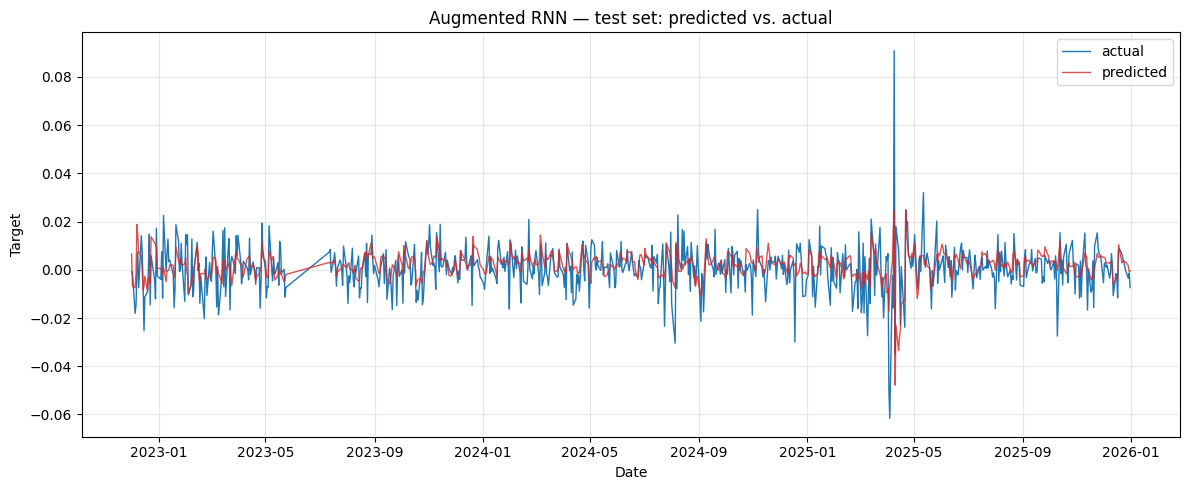

In [11]:
plotting.plot_predictions_vs_actual(
    res['targets'], res['predictions'], index=test_dates,
    title='Augmented RNN — test set: predicted vs. actual',
)
plt.show()


## 6. Save the run to the Shared Drive

Colab sessions are ephemeral and a tuning run is expensive, so everything needed to reuse or audit this run is written to one timestamped folder under `DRIVE_MODELS_PATH`: the model weights and the architecture args needed to rebuild them, the fitted scaler (required for correct inference later), the winning config, the full tuning history, the frozen test predictions, and provenance (dataset, split, seed, git commit).

Saving as `'augmented'` (vs. Stage 03's `'baseline'`) means **Stage 05 can load both runs and compare them head-to-head without retraining anything**.


In [12]:
run_dir = artifacts.save_run(
    'augmented',
    res['model'],
    best.config,
    metrics={
        'test_rmse': res['test_rmse'],
        'test_directional_accuracy': res['test_directional_accuracy'],
        'best_val_rmse': best.metrics['val_rmse'],
    },
    scaler=res['scaler'],
    trials=results_df,
    learning_curves=curves,
    predictions=res['predictions'],
    targets=res['targets'],
    dates=test_dates,
    train_loss_history=res['train_loss_history'],
    extra_metadata={
        'dataset_file': WINDOW_FILE,
        'window_shape': list(X.shape),
        'num_features': int(X.shape[-1]),
        'horizon': int(y.shape[-1]),
        'n_dev': int(len(X_dev)),
        'n_test': int(len(X_test)),
        'test_frac': TEST_FRAC,
        'n_folds': tune_kwargs['n_folds'],
        'num_samples': tune_kwargs['num_samples'],
        'max_epochs': tune_kwargs['max_epochs'],
        'scaler': 'StandardScaler',
        'smoke_test': SMOKE_TEST,
    },
)

print('Saved run ->', run_dir)
for item in sorted(os.listdir(run_dir)):
    print('  ', item)


Saved run -> /content/drive/Shareddrives/COMP 653 - Final Project/saved_models/augmented_20260812_045919
   learning_curves.csv
   manifest.json
   model.pt
   scaler.joblib
   test_predictions.csv
   tuning_trials.csv


In [13]:
# Reload from the Drive and confirm the saved weights reproduce the metrics.
loaded = artifacts.load_run(artifacts.find_latest_run('augmented'))

x_test_scaled = loaded['scaler'].transform(
    X_test.reshape(-1, X_test.shape[-1])
).reshape(X_test.shape)
with torch.no_grad():
    reloaded_preds = loaded['model'](
        torch.as_tensor(x_test_scaled, dtype=torch.float32)
    ).numpy()

print('max |reloaded - original| prediction diff:',
      float(np.abs(reloaded_preds - res['predictions']).max()))
print('manifest metrics:', loaded['manifest']['metrics'])


max |reloaded - original| prediction diff: 0.0
manifest metrics: {'test_rmse': 0.008491171862753676, 'test_directional_accuracy': 0.6698113207547169, 'best_val_rmse': 0.009813034233856942}


## Summary

The **pattern-augmented** `RNNForecaster` has been tuned via walk-forward CV on the same schedule as Stage 03, evaluated on the held-out test period, and the complete run (weights, scaler, config, tuning history, predictions, provenance) saved to the Shared Drive under `'augmented'`.

**Next:** Stage 05 loads both the `'baseline'` and `'augmented'` saved runs and compares them head-to-head -- test RMSE, directional accuracy, and predictions over time -- without retraining either.
